# Projet ML for Econometrics

## Introduction

Ce notebook retrace l'ensemble de notre travail effectué dans le cadre du projet pour le cours de ML for Econometrics présenté par Mr. Doutreligne et Mr. Crépon

## Présentation de la base de données et de la problématique

Nous nous appuyons sur le dataset "Predict Students' Dropout and Academic Success" qui est une base de données disponible publiquement via le lien suivant https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success

Cette base de données répertorie le parcours scolaire de 4424 étudiants dans différents cursus (agronomie, design, infirmier, etc.). La BDD donne pour chaque individu de nombreuses informations socio-démographiques de l'élève (sexe, âge, niveau scolaire des deux parents, nationalité, etc.) ainsi que des données sur son parcours scolaire (note durant les deux semestres de l'année) ainsi que la situation de l'élève à la fin du temps scolaire.

Cette dernière variable est ici notre variable d'intérêt, elle peut prendre trois valeurs différentes : dropout si l'élève a abandonné les études, graduate si l'élève a été diplômé, ou enrolled si l'élève continue les cours dans un temps supplémentaire.

Notre travail se concentre sur la recherche de l'effet causal d'avoir une bourse d'études sur la réussite de l'élève.

## Formulation PICO de notre problématique

P : La population étudiée ici est un ensemble d'étudiants étant en études entre 2008 et 2018

I : L'intervention que l'on considère ici est le fait de recevoir une bourse durant ses études

C : On compare cela avec les étudiants n'ayant pas reçu de bourse durant leur études

O : L'outcome considéré est le fait d'obtenir son diplôme à la fin du parcours scolaire

## Introduction, analyse sociologique et DAG

## Analyse descriptive des données

L'objectif de cette seconde partie est de visualiser en détails la base de données, en particulier on s'attardera particulièrement sur l'outcome et sur les variables corrélées avec le fait d'avoir une bourse

### Téléchargement des données et nettoyage de la BDD

In [62]:
#pip install ucimlrepo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo 


In [63]:

print("--- 1. Chargement du dataset ---")
dataset = fetch_ucirepo(id=697) 
X = dataset.data.features 
y = dataset.data.targets 
X["Application mode"] = X["Application mode"].astype(str)
X["Course"] = X["Course"].astype(str)
X["Father\'s occupation"] = X["Father\'s occupation"].astype(str)
X["Mother\'s occupation"] = X["Mother\'s occupation"].astype(str)
X["Father\'s qualification"] = X["Father\'s qualification"].astype(str)
X["Mother\'s qualification"] = X["Mother\'s qualification"].astype(str)
X["Marital Status"] = X["Marital Status"].astype(str)
X["Nacionality"] = X["Nacionality"].astype(str)
X["Previous qualification"] = X["Previous qualification"].astype(str)
df = pd.concat([X, y], axis=1)

print(f"Dimensions du dataset : {df.shape[0]} lignes, {df.shape[1]} colonnes\n")

print("--- 2. Types de variables et Valeurs manquantes ---")
valeurs_manquantes = pd.DataFrame({
    'Type': df.dtypes,
    'Manquants (%)': (df.isnull().sum() / len(df) * 100).round(2),
    'Valeurs Uniques': df.nunique()
})
print(valeurs_manquantes)

print("\n--- 3. Statistiques Descriptives ---")
display(df.describe().T.round(2))

--- 1. Chargement du dataset ---
Dimensions du dataset : 4424 lignes, 37 colonnes

--- 2. Types de variables et Valeurs manquantes ---
                                                   Type  Manquants (%)  \
Marital Status                                   object            0.0   
Application mode                                 object            0.0   
Application order                                 int64            0.0   
Course                                           object            0.0   
Daytime/evening attendance                        int64            0.0   
Previous qualification                           object            0.0   
Previous qualification (grade)                  float64            0.0   
Nacionality                                      object            0.0   
Mother's qualification                           object            0.0   
Father's qualification                           object            0.0   
Mother's occupation                              ob

/tmp/ipykernel_35243/280577157.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Application mode"] = X["Application mode"].astype(str)
/tmp/ipykernel_35243/280577157.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Course"] = X["Course"].astype(str)
/tmp/ipykernel_35243/280577157.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/

,count,mean,std,min,25%,50%,75%,max
Application order,4424.0,1.73,1.31,0.00,1.00,1.00,2.00,9.00
Daytime/evening attendance,4424.0,0.89,0.31,0.00,1.00,1.00,1.00,1.00
Previous qualification (grade),4424.0,132.61,13.19,95.00,125.00,133.10,140.00,190.00
Admission grade,4424.0,126.98,14.48,95.00,117.90,126.10,134.80,190.00
Displaced,4424.0,0.55,0.50,0.00,0.00,1.00,1.00,1.00
Educational special needs,4424.0,0.01,0.11,0.00,0.00,0.00,0.00,1.00
Debtor,4424.0,0.11,0.32,0.00,0.00,0.00,0.00,1.00
Tuition fees up to date,4424.0,0.88,0.32,0.00,1.00,1.00,1.00,1.00
Gender,4424.0,0.35,0.48,0.00,0.00,0.00,1.00,1.00
Scholarship holder,4424.0,0.25,0.43,0.00,0.00,0.00,0.00,1.00


Comme nous le montrent ces résultats, la base de données ne contient pas de valeur manquante.

Cependant, ce résultat cache d'une certaine façon la réalité : Rappelons que dans note BDD, certains élèves abandonnent leurs études au cours de l'année.
Ainsi, les variables inquant le nombre d'ECTS crédités par semestre ainsi que les notes des élèves n'a pas trop de signification : en effet, un élève qui abandonne son année aura administrativement des notes nulles pour le reste de l'année.

Comme l'idée de notre projet est d'étudier les facteurs qui influent en amont sur le fait d'avoir une bourse et de réussir son année, ces variables en question ne semblent pas pertinentes et risquent de nous induire en erreur. Ainsi, on les supprime du dataset

Notons également que certaines variables, comme le travail des parents ou la nationalité de l'élève, sont des variables nominales encodées en entier. Il est donc important de les transformer en string pour ne pas faire d'erreur par la suite.

In [64]:
df["Mother\'s occupation"].value_counts()

Mother's occupation
9      1577
4       817
5       530
3       351
2       318
7       272
0       144
1       102
6        91
90       70
8        36
191      26
99       17
194      11
141       8
123       7
144       6
175       5
192       5
10        4
134       4
193       4
151       3
132       3
143       3
153       2
152       2
122       2
125       1
173       1
131       1
171       1
Name: count, dtype: int64

Lorsque l'on regarde les variables indiquant les métiers des parents de l'élève, on note que cela correspond plus au moins au code ISCO (nomenclature européenne des métiers). Au détails près que certains individus sont associés avec un métier plus précis (2 digits), pour les reconnaître, ce sont ceux qui commençent par un "1".

Comme cela représente que très peu d'individus, on agrège l'information au premier digit (ainsi 123 qui correspond au métier de professeur (teacher, code ISCO 23) est compris dans la section 2 : professionnels).

In [65]:

data_propre = df.drop([

    "Curricular units 1st sem (credited)",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (without evaluations)",
    
    "Curricular units 2nd sem (credited)",
    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 2nd sem (without evaluations)"

], axis=1)

#Pour les variables d'occupation des parents, on agrège au premier chiffre de la nomenclature ISCO
def agrege_occupation(row):
    s = row
    if isinstance(s, str) and len(s) == 3:
        return s[1]
    else:
        return s

data_propre["Father_occupation_sector"] = data_propre["Father\'s occupation"].apply(agrege_occupation)
data_propre["Mother_occupation_sector"] = data_propre["Mother\'s occupation"].apply(agrege_occupation)


data_propre = data_propre.drop(["Father\'s occupation","Mother\'s occupation"], axis=1)
data_propre["Father_occupation_sector"] = data_propre["Father_occupation_sector"].map({
    "0": "Student",
    "1": "Managers",
    "2": "Professionals",
    "3": "Technicians",
    "4": "Clerical Support Workers",
    "5": "Services and Sales Workers",
    "6": "Skilled Workers",
    "7": "Craft Workers",
    "8": "Plant Operators",
    "9": "Elementary Occupations",
    "10": "Tourism",
    "90": "Other situation",
    "99": "No response",
    })
    
data_propre["Mother_occupation_sector"] = data_propre["Mother_occupation_sector"].map({
    "0": "Student",
    "1": "Managers",
    "2": "Professionals",
    "3": "Technicians",
    "4": "Clerical Support Workers",
    "5": "Services and Sales Workers",
    "6": "Skilled Workers",
    "7": "Craft Workers",
    "8": "Plant Operators",
    "9": "Elementary Occupations",
    "10": "Tourism",
    "90": "Other situation",
    "99": "No response",
    })


#On renomme les valeurs de certaines variables catégorielles pour une meilleure compréhension des données
data_propre["Course"] = data_propre["Course"].map({
    "33": "Biofuel Production",
    "171": "Animation Design",
    "8014": "Social Service (evening)",
    "9003": "Agronomy",
    "9070": "Communiation Design",
    "9085": "Veterinary",
    "9119": "Informatics",
    "9130": "Equiculture",
    "9147": "Management",
    "9238": "Social Service",
    "9254": "Tourism",
    "9500": "Nursing",
    "9556": "Oral Hygiene",
    "9670": "Marketing",
    "9773": "Journalism",
    "9853": "Education",
    "9991": "Management (evening)",
    })

data_propre["Daytime/evening attendance"] = data_propre["Daytime/evening attendance"].map({
    1: "Daytime",    
    0: "Evening",
    })

data_propre["Gender"] = data_propre["Gender"].map({
    1: "Male",    
    0: "Female",
    })

data_propre["Scholarship holder"] = data_propre["Scholarship holder"].map({
    1: "Boursier",    
    0: "Non-Boursier",
    })

data_propre["International"] = data_propre["International"].map({
    1: "Yes",    
    0: "No",
    })


categorie_graduate = ['Dropout', 'Enrolled', 'Graduate']
data_propre['Target'] = pd.Categorical(data_propre['Target'], categories=categorie_graduate, ordered=True)


In [66]:
data_propre.describe(include="all")

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Gender,Scholarship holder,Age at enrollment,International,Unemployment rate,Inflation rate,GDP,Target,Father_occupation_sector,Mother_occupation_sector
count,4424,4424,4424.000000,4424,4424,4424,4424.000000,4424,4424,4424,...,4424,4424,4424.000000,4424,4424.000000,4424.000000,4424.000000,4424,4424,4424
unique,6,18,NaN,17,2,17,NaN,21,29,34,...,2,2,NaN,2,NaN,NaN,NaN,3,13,13
top,1,1,NaN,Nursing,Daytime,1,NaN,1,1,37,...,Female,Non-Boursier,NaN,No,NaN,NaN,NaN,Graduate,Elementary Occupations,Elementary Occupations
freq,3919,1708,NaN,766,3941,3717,NaN,4314,1069,1209,...,2868,3325,NaN,4314,NaN,NaN,NaN,2209,1034,1623
mean,NaN,NaN,1.727848,NaN,NaN,NaN,132.613314,NaN,NaN,NaN,...,NaN,NaN,23.265145,NaN,11.566139,1.228029,0.001969,NaN,NaN,NaN
std,NaN,NaN,1.313793,NaN,NaN,NaN,13.188332,NaN,NaN,NaN,...,NaN,NaN,7.587816,NaN,2.663850,1.382711,2.269935,NaN,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,NaN,95.000000,NaN,NaN,NaN,...,NaN,NaN,17.000000,NaN,7.600000,-0.800000,-4.060000,NaN,NaN,NaN
25%,NaN,NaN,1.000000,NaN,NaN,NaN,125.000000,NaN,NaN,NaN,...,NaN,NaN,19.000000,NaN,9.400000,0.300000,-1.700000,NaN,NaN,NaN
50%,NaN,NaN,1.000000,NaN,NaN,NaN,133.100000,NaN,NaN,NaN,...,NaN,NaN,20.000000,NaN,11.100000,1.400000,0.320000,NaN,NaN,NaN
75%,NaN,NaN,2.000000,NaN,NaN,NaN,140.000000,NaN,NaN,NaN,...,NaN,NaN,25.000000,NaN,13.900000,2.600000,1.790000,NaN,NaN,NaN


### Statistiques Descriptives

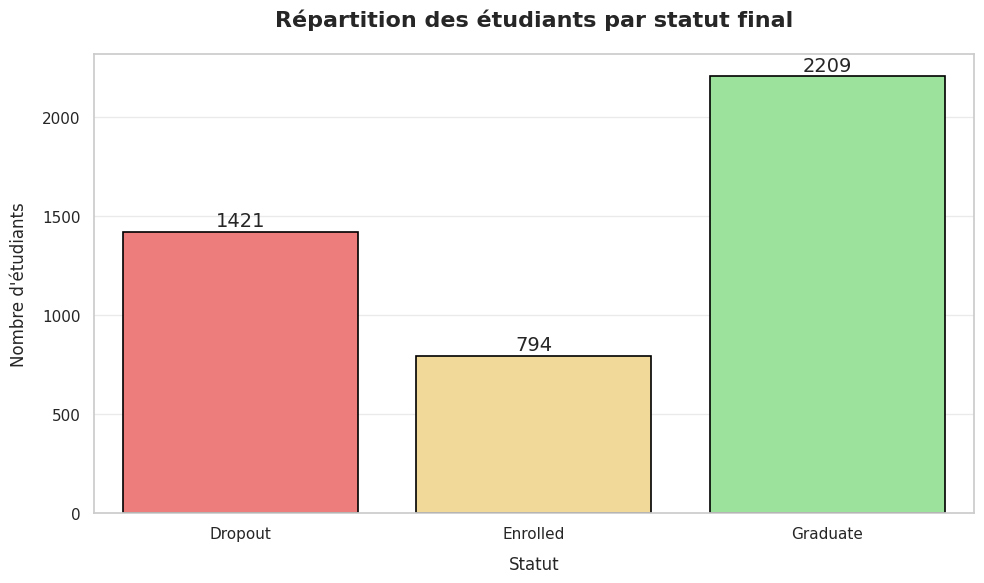

In [67]:
couleurs = {"Dropout": "#FF6B6B", "Enrolled": "#FFE08A", "Graduate": "#90EE90"}

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

plt.figure(figsize=(10, 6))
ax = sns.countplot(
    data=data_propre,
    x='Target',
    hue='Target',
    palette=couleurs,
    legend=False,
    edgecolor='black',
    linewidth=1.2
)
plt.title("Répartition des étudiants par statut final", fontsize=16, pad=20, weight='bold')
plt.xlabel("Statut", fontsize=12, labelpad=10)
plt.ylabel("Nombre d'étudiants", fontsize=12, labelpad=10)
plt.xticks(rotation=0, fontsize=11)

ax.grid(axis='y', alpha=0.4)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 8),
        textcoords='offset points',
        fontsize=14
    )
plt.tight_layout()
plt.show()


On note ainsi que les trois catégories de notre outcome ne sont pas pas présentes dans les mêmes proportions dans ce dataset. Si une majorité des élèves sont diplômés à la fin de l'année, un tiers des élèves abandonne les études durant l'année. Pour la dernière catégorie, cela représente les élèves qui n'ont pas validé dans le temps réglementaire, ils sont donc encore inscrits pour finir leur cursus. Cela représente un peu moins de 18% des élèves.

<Figure size 1200x800 with 0 Axes>

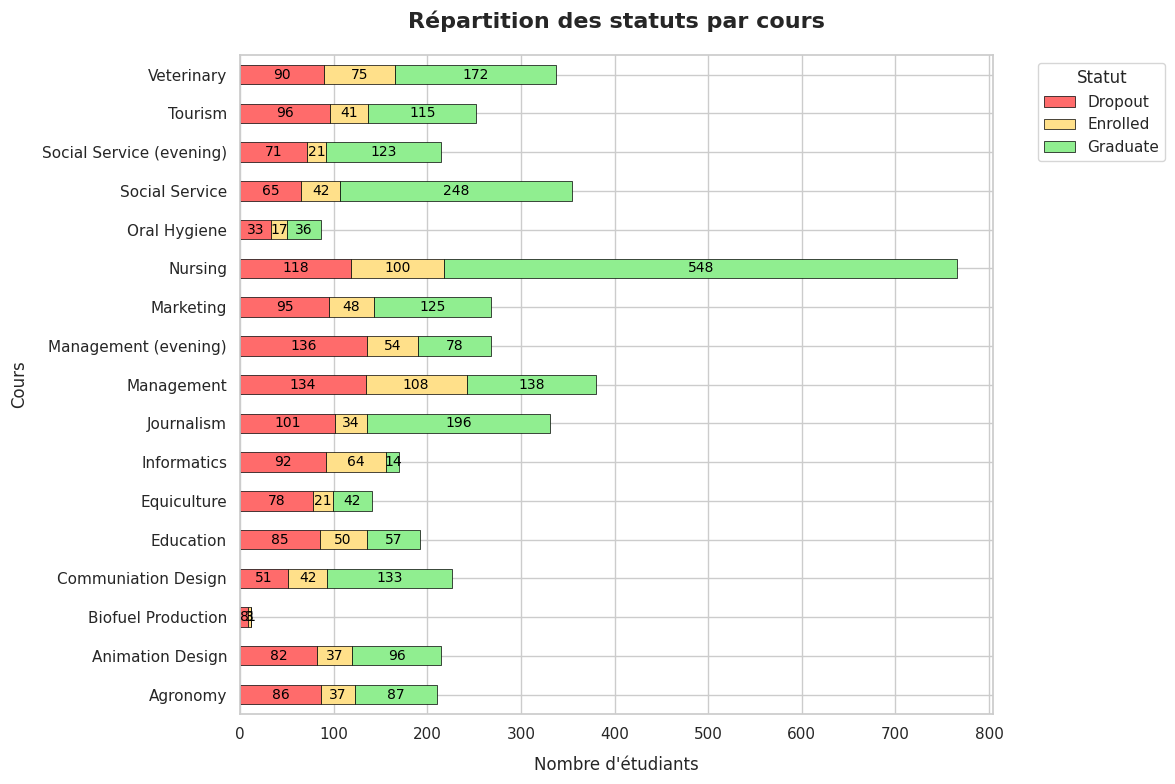

In [68]:
# Préparation des données : comptage des occurrences par cours et par statut
cross_tab = pd.crosstab(data_propre['Course'], data_propre['Target'])

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

plt.figure(figsize=(12, 8))
ax = cross_tab.plot(kind='barh', stacked=True, color=[couleurs['Dropout'], couleurs['Enrolled'], couleurs['Graduate']], edgecolor='black', linewidth=0.5)

plt.title("Répartition des statuts par cours", fontsize=16, pad=20, weight='bold')
plt.xlabel("Nombre d'étudiants", fontsize=12, labelpad=10)
plt.ylabel("Cours", fontsize=12, labelpad=10)

plt.legend(title='Statut', bbox_to_anchor=(1.05, 1), loc='upper left')

for container in ax.containers:
    ax.bar_label(container, label_type='center', fmt='%d', padding=0, fontsize=10, color='black')

plt.tight_layout()
plt.show()


On note ici que quelque soit les études, certains élèves les ont réussi, d'autres ont échoué, et d'autres sont encore en cours d'études.

En revanche, certaines études semblent plus "simples" que d'autres. Par exemple, les études d'infirmier possède un taux de réussite bien plus élevé que les études d'informatique (72% de diplômés contre 8% pour les études d'informatique)